## **Librerias Importadas**

In [3]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.notebook_repr_html', True)
import seaborn as sns
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')
import string
import math
import sys
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
import sklearn
from IPython.core.interactiveshell import InteractiveShell

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from tensorflow.keras.utils import plot_model
from sklearn.ensemble import RandomForestClassifier

InteractiveShell.ast_node_interactivity = "all"

## **Análisis de los Datos**

In [55]:
df_beans = pd.read_excel("./Dry_Bean_Dataset.xlsx", names = ["Area","Perimeter","MajorAxisLength", "MinorAxisLength", "AspectRation", "Eccentricity", "ConvexArea", "EquivDiameter", "Extent", "Solidity", "roundness", "Compactness", "ShapeFactor1", "ShapeFactor2", "ShapeFactor3", "ShapeFactor4", "class"])
df_beans.head()
df_beans.info()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  class            13611 non-null  object 
dtypes: float64(1

In [56]:
df_beans.count()
print(f"Número de filas duplicadas: {df_beans.duplicated().sum()}")
df_beans.drop_duplicates(inplace=True)
print(f"Número de filas duplicadas despues del borrado: {df_beans.duplicated().sum()}")

,0
Area,13611
Perimeter,13611
MajorAxisLength,13611
MinorAxisLength,13611
AspectRation,13611
Eccentricity,13611
ConvexArea,13611
EquivDiameter,13611
Extent,13611
Solidity,13611


Número de filas duplicadas: 68
Número de filas duplicadas despues del borrado: 0


<Figure size 1000x300 with 0 Axes>

<Axes: xlabel='class', ylabel='count'>

Text(0.5, 1.0, 'Distribución de Datos por Clases')

Text(0.5, 0, 'Clases')

Text(0, 0.5, 'Cantidad')

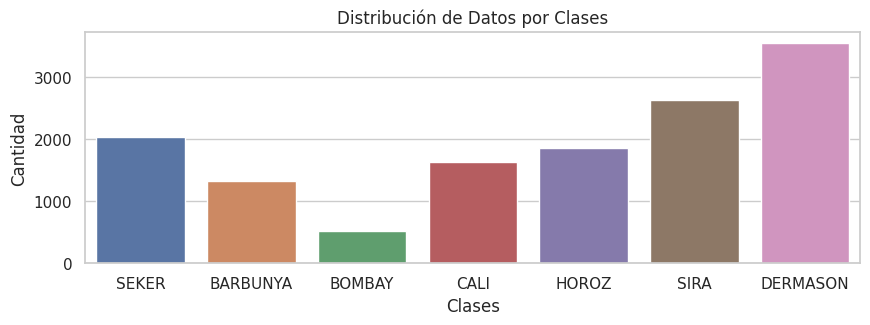

In [57]:
plt.figure(figsize=(10, 3))
sns.countplot(data=df_beans, x='class', hue='class', legend=False)
plt.title('Distribución de Datos por Clases')
plt.xlabel('Clases')
plt.ylabel('Cantidad')
plt.show()

In [58]:
df_beans['class'].value_counts()

,count
class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1860
CALI,1630
BARBUNYA,1322
BOMBAY,522


<Axes: >

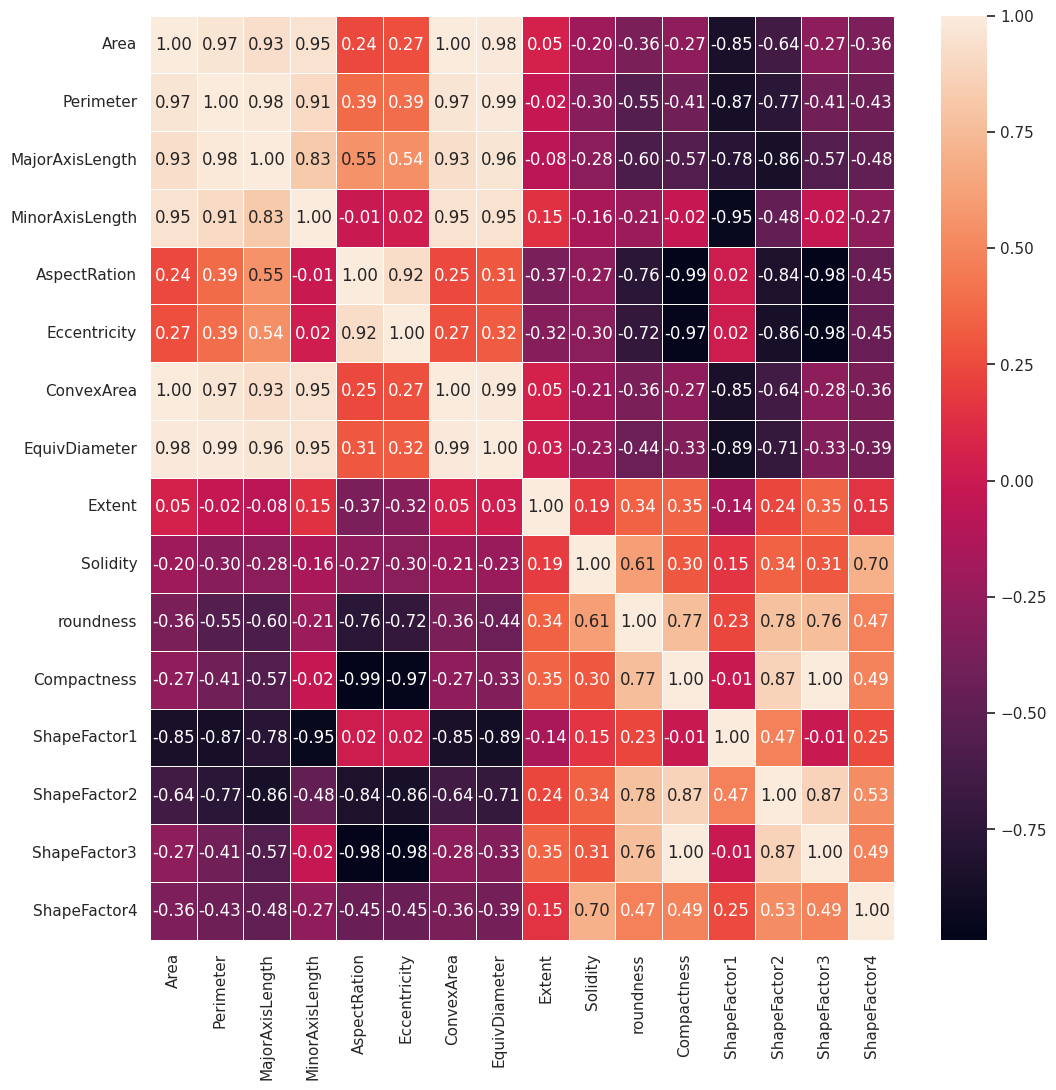

In [59]:
df_filt = df_beans.drop(columns=["Perimeter",
        "MajorAxisLength",
        "MinorAxisLength",
        "ConvexArea",
        "EquivDiameter",
        "ShapeFactor3",])
f,ax = plt.subplots(figsize=(12, 12))
sns.heatmap(df_beans.corr(numeric_only=True), annot=True, linewidths=0.5, fmt='.2f',ax=ax)


## **Separación de los Datos (Split)**

In [60]:
x = df_beans.drop(columns=['class'])
y_raw = df_beans['class']

le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
target_names = le.classes_.tolist()

x_train, x_test, y_train, y_test = train_test_split(
    x, y_encoded, train_size=0.8, test_size=0.2, random_state=67,
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

print(f"Número de características (dimensiones): {len(x.columns)}")
print(f"Variedades de frijoles a clasificar ({len(target_names)}): {target_names}")
print(f"Forma de x_train_scaled: {x_train_scaled.shape}")
print(f"Forma de y_train_encoded: {y_train_encoded.shape}")
print(f"Primer elemento en el one-hot encoded training set:\n{x_train_scaled[:1]}")
print(f"Primer acierto en el one-hot encoded training set:\n{y_train_encoded[:1]}")

Número de características (dimensiones): 16
Variedades de frijoles a clasificar (7): ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Forma de x_train_scaled: (10834, 16)
Forma de y_train_encoded: (10834, 7)
Primer elemento en el one-hot encoded training set:
[[ 0.23476181  0.39985156  0.48777768  0.34246601  0.32900282  0.52587916
   0.27145027  0.39218471 -1.00702656 -4.02879031 -0.38220341 -0.59778045
  -0.46813927 -0.7620361  -0.62067763 -6.08842346]]
Primer acierto en el one-hot encoded training set:
[[0. 0. 0. 0. 1. 0. 0.]]


## **Modelo Sigmoid**

In [72]:
modelSig = keras.Sequential([
    layers.Input(shape=(x_train_scaled.shape[1],)),
    layers.Dense(12, activation='sigmoid', name='hidden_layer_1'),
    layers.Dense(3, activation='sigmoid', name='hidden_layer_2'),
    layers.Dense(y_train_encoded.shape[1], activation='sigmoid', name='output_layer')
])

optimizer_adam = keras.optimizers.Adam(learning_rate=0.3)

modelSig.compile(
    optimizer=optimizer_adam,
    loss='categorical_crossentropy',
    metrics=['accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.F1Score(name='f1_score', average='macro')]
)

modelSig.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 3)              │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │            28 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271 (1.06 KB)

 Trainable params: 271 (1.06 KB)

 Non-trainable params: 0 (0.00 B)

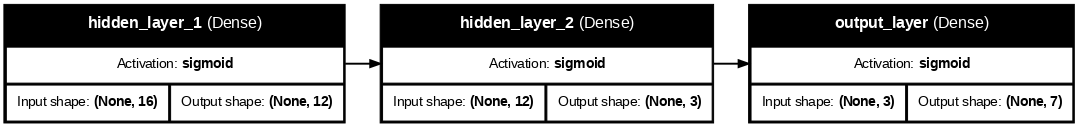

In [73]:
plot_model(
    modelSig,
    show_shapes=True,
    show_layer_names=True,
    dpi=70,
    rankdir = 'LR',
    show_layer_activations = True
)

### **Entrenamiento**

In [74]:
historySig = modelSig.fit(
    x_train_scaled, y_train_encoded,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
)

Epoch 1/200
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4901 - f1_score: 0.4091 - loss: 1.1940 - recall: 0.9286 - val_accuracy: 0.4301 - val_f1_score: 0.3388 - val_loss: 1.2318 - val_recall: 0.9705
Epoch 2/200
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5939 - f1_score: 0.5025 - loss: 0.9747 - recall: 0.9401 - val_accuracy: 0.6484 - val_f1_score: 0.4593 - val_loss: 0.8300 - val_recall: 0.9871
Epoch 3/200
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5857 - f1_score: 0.5023 - loss: 0.9520 - recall: 0.9664 - val_accuracy: 0.6617 - val_f1_score: 0.4982 - val_loss: 0.8894 - val_recall: 0.9866
Epoch 4/200
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5829 - f1_score: 0.4992 - loss: 0.9519 - recall: 0.9710 - val_accuracy: 0.6447 - val_f1_score: 0.4591 - val_loss: 0.8588 - val_recall: 0.9705
Epoch 5/200
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5588 - f1_score: 0.4883 - loss: 1.0299 - recall: 0.9755 - val_accuracy: 0.5916 - val_f1

###**Test**

In [75]:
predictionsSig = modelSig.predict(x_test_scaled)
predicted_classesSig = np.argmax(predictionsSig, axis=1)

true_classesSig = np.argmax(y_test_encoded, axis=1)

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


### **Matriz de confusión**

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'BARBUNYA'),
  Text(1, 0, 'BOMBAY'),
  Text(2, 0, 'CALI'),
  Text(3, 0, 'DERMASON'),
  Text(4, 0, 'HOROZ'),
  Text(5, 0, 'SEKER'),
  Text(6, 0, 'SIRA')])

Text(0.5, 1.0, 'Matriz de Confusión (Sigmoid)')

Text(0.5, 0, 'Predicciones')

Text(0, 0.5, 'Valores Verdaderos')

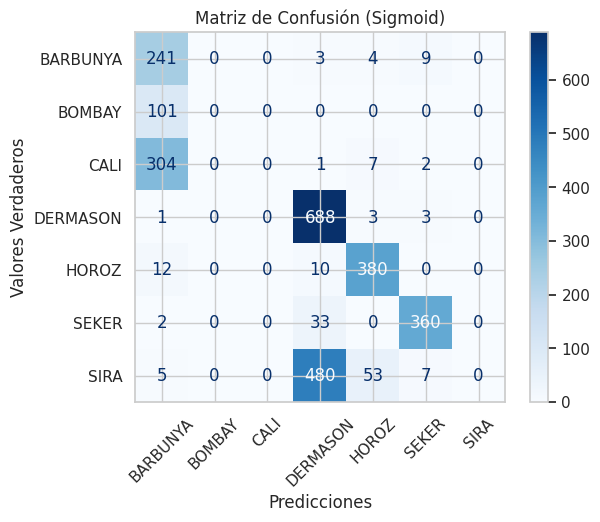

In [76]:
labels = ['BARBUNYA','BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
confusion_matrix_model = confusion_matrix(true_classesSig, predicted_classesSig)
display_matrix = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_model, display_labels=labels)
display_matrix.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45)
plt.title('Matriz de Confusión (Sigmoid)')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.show()

### **Grafícas de Accuracy y Loss**

In [77]:
print(f"Precisión en Test: {accuracy_score(y_test, predicted_classesSig):.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, predicted_classesSig, target_names=target_names))

Precisión en Test: 0.6161

Reporte de Clasificación:
              precision    recall  f1-score   support

    BARBUNYA       0.36      0.94      0.52       257
      BOMBAY       0.00      0.00      0.00       101
        CALI       0.00      0.00      0.00       314
    DERMASON       0.57      0.99      0.72       695
       HOROZ       0.85      0.95      0.90       402
       SEKER       0.94      0.91      0.93       395
        SIRA       0.00      0.00      0.00       545

    accuracy                           0.62      2709
   macro avg       0.39      0.54      0.44      2709
weighted avg       0.44      0.62      0.50      2709



<Figure size 1200x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Precisión del Modelo (Sigmoid)')

Text(0.5, 0, 'Épocas')

Text(0, 0.5, 'Precisión')

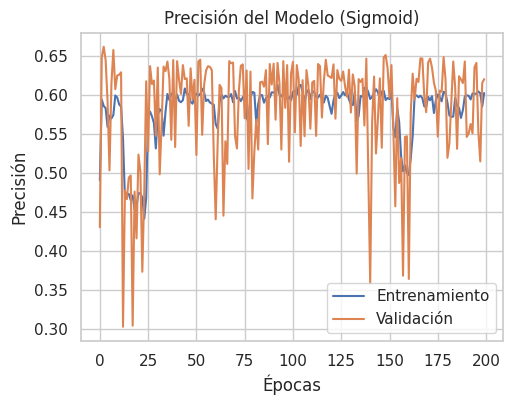

In [78]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historySig.history['accuracy'], label='Entrenamiento')
plt.plot(historySig.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo (Sigmoid)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.show()

<Figure size 1200x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Pérdida del Modelo (Sigmoid)')

Text(0.5, 0, 'Épocas')

Text(0, 0.5, 'Pérdida')

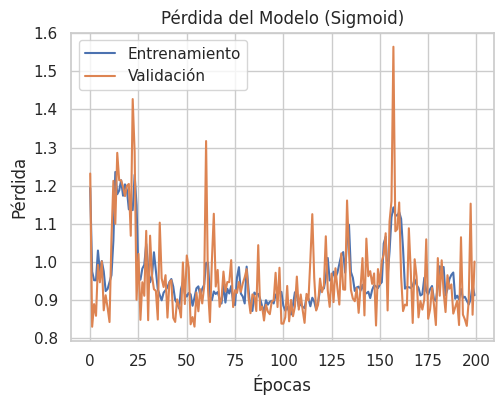

In [79]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 2)
plt.plot(historySig.history['loss'], label='Entrenamiento')
plt.plot(historySig.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo (Sigmoid)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.show()

## **Modelo Relu/Softmax**

In [64]:

model = keras.Sequential([
    layers.Input(shape=(x_train_scaled.shape[1],)),
    layers.Dense(12, activation='relu', name='hidden_layer_1'),
    layers.Dense(3, activation='relu', name='hidden_layer_2'),
    layers.Dense(y_train_encoded.shape[1], activation='softmax', name='output_layer')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.F1Score(name='f1_score', average='macro')]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 3)              │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │            28 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271 (1.06 KB)

 Trainable params: 271 (1.06 KB)

 Non-trainable params: 0 (0.00 B)

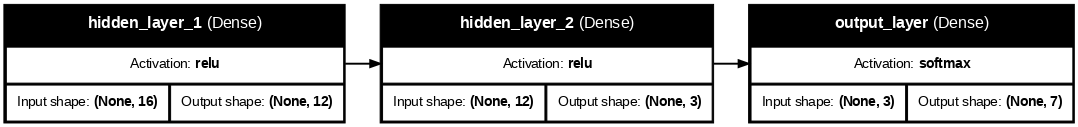

In [65]:
plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    dpi=70,
    rankdir = 'LR',
    show_layer_activations = True
)

### **Entrenamiento**

In [66]:
history = model.fit(
    x_train_scaled, y_train_encoded,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
)

Epoch 1/200
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4579 - f1_score: 0.3906 - loss: 1.3282 - recall: 0.2550 - val_accuracy: 0.7393 - val_f1_score: 0.7263 - val_loss: 0.8901 - val_recall: 0.3849
Epoch 2/200
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7988 - f1_score: 0.8207 - loss: 0.7051 - recall: 0.5477 - val_accuracy: 0.8574 - val_f1_score: 0.8755 - val_loss: 0.5649 - val_recall: 0.6904
Epoch 3/200
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8681 - f1_score: 0.8884 - loss: 0.5070 - recall: 0.7362 - val_accuracy: 0.8929 - val_f1_score: 0.9063 - val_loss: 0.4529 - val_recall: 0.8634
Epoch 4/200
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8890 - f1_score: 0.9059 - loss: 0.4171 - recall: 0.8670 - val_accuracy: 0.9012 - val_f1_score: 0.9133 - val_loss: 0.3883 - val_recall: 0.8883
Epoch 5/200
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8963 - f1_score: 0.9119 - loss: 0.3651 - recall: 0.8835 - val_accuracy: 0.9063 - val_f1

### **Test**

In [67]:
predictions = model.predict(x_test_scaled)
predicted_classesRS = np.argmax(predictions, axis=1)

true_classesRS = np.argmax(y_test_encoded, axis=1)

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


### **Matriz de confusión**

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'BARBUNYA'),
  Text(1, 0, 'BOMBAY'),
  Text(2, 0, 'CALI'),
  Text(3, 0, 'DERMASON'),
  Text(4, 0, 'HOROZ'),
  Text(5, 0, 'SEKER'),
  Text(6, 0, 'SIRA')])

Text(0.5, 1.0, 'Matriz de Confusión (Relu/Softmax)')

Text(0.5, 0, 'Predicciones')

Text(0, 0.5, 'Valores Verdaderos')

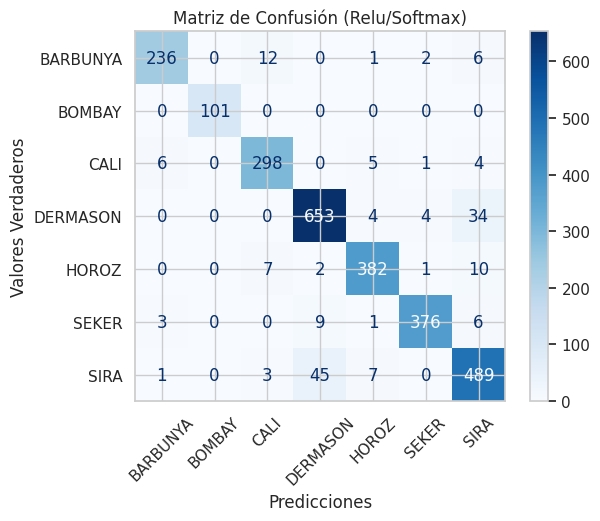

In [68]:
labels = ['BARBUNYA','BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
confusion_matrix_model = confusion_matrix(true_classesRS, predicted_classesRS)
display_matrix = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_model, display_labels=labels)
display_matrix.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45)
plt.title('Matriz de Confusión (Relu/Softmax)')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.show()

### **Graficas de Accuracy y Loss**

In [69]:
print(f"Precisión en Test: {accuracy_score(y_test, predicted_classesRS):.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, predicted_classesRS, target_names=target_names))

Precisión en Test: 0.9358

Reporte de Clasificación:
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.92      0.94       257
      BOMBAY       1.00      1.00      1.00       101
        CALI       0.93      0.95      0.94       314
    DERMASON       0.92      0.94      0.93       695
       HOROZ       0.95      0.95      0.95       402
       SEKER       0.98      0.95      0.97       395
        SIRA       0.89      0.90      0.89       545

    accuracy                           0.94      2709
   macro avg       0.95      0.94      0.95      2709
weighted avg       0.94      0.94      0.94      2709



<Figure size 1200x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Precisión del Modelo (Relu/Softmax)')

Text(0.5, 0, 'Épocas')

Text(0, 0.5, 'Precisión')

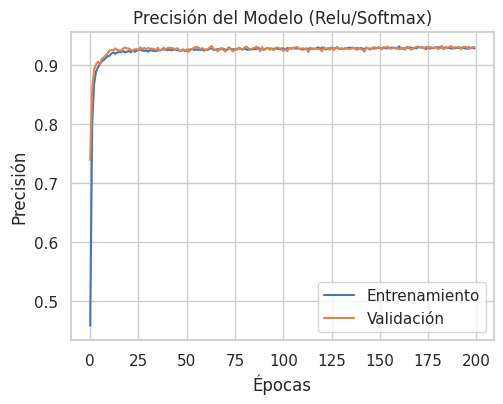

In [70]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo (Relu/Softmax)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.show()

<Figure size 1200x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Pérdida del Modelo (Relu/Softmax)')

Text(0.5, 0, 'Épocas')

Text(0, 0.5, 'Pérdida')

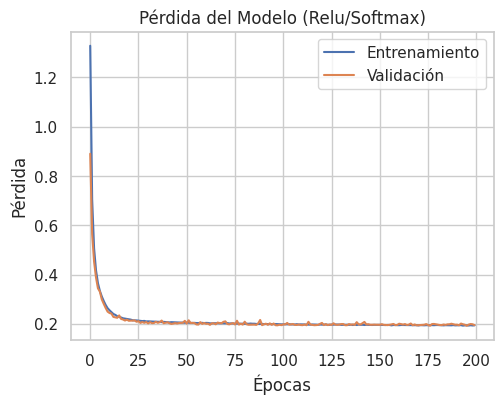

In [71]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo (Relu/Softmax)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.show()

## **Modelo Random Forest**

In [61]:
model_forest = RandomForestClassifier(n_estimators=300, random_state=67)

model_forest.fit(x_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=67)

In [62]:
predicted_classesRF = model_forest.predict(x_test)

In [63]:
print(f"Precisión en Test: {accuracy_score(y_test, predicted_classesRF):.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, predicted_classesRF, target_names=target_names))

Precisión en Test: 0.9284

Reporte de Clasificación:
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.91      0.94       257
      BOMBAY       0.99      1.00      1.00       101
        CALI       0.93      0.95      0.94       314
    DERMASON       0.91      0.93      0.92       695
       HOROZ       0.95      0.94      0.95       402
       SEKER       0.96      0.96      0.96       395
        SIRA       0.88      0.87      0.87       545

    accuracy                           0.93      2709
   macro avg       0.94      0.94      0.94      2709
weighted avg       0.93      0.93      0.93      2709



(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'BARBUNYA'),
  Text(1, 0, 'BOMBAY'),
  Text(2, 0, 'CALI'),
  Text(3, 0, 'DERMASON'),
  Text(4, 0, 'HOROZ'),
  Text(5, 0, 'SEKER'),
  Text(6, 0, 'SIRA')])

Text(0.5, 1.0, 'Matriz de Confusión (Random Forest)')

Text(0.5, 0, 'Predicciones')

Text(0, 0.5, 'Valores Verdaderos')

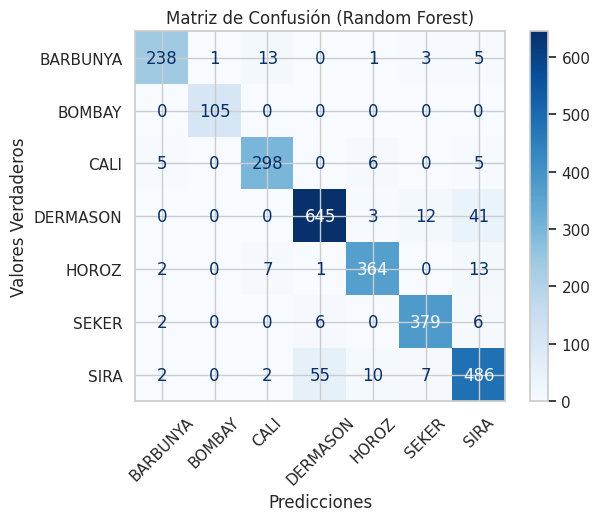

In [45]:
labels = ['BARBUNYA','BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']

cm = confusion_matrix(y_test, predicted_classesRF)

display_matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
display_matrix.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45)

plt.title('Matriz de Confusión (Random Forest)')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.show()